In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## Defining the talent formula

In [31]:
talent_dict = {
    "Technical score": {
        "Current ability": 0.15,
        "Training hours": 0.10,
        "Innovative contributions": 0.10,
        "Contribution to special projects": 0.10,
        "AI use": 0.025,
        "AI confidence": 0.025,
    },
    "Personal score": {
        "Performance": 0.10,
        "Engagement": 0.05,
        "Work-life balance": 0.05,
        "Job stress": 0.05,
    },
    "Interpersonal score": {
        "Feedback and collaboration": 0.10,
        "Teamwork": 0.05,
        "Networking": 0.05,
        "Colleague assessment": 0.05,

    },
}


df["technical_score"] = (
    talent_dict["Technical score"]["Current ability"] * df["TechLev"] +
    talent_dict["Technical score"]["Training hours"] * df["TrainHours"] +
    talent_dict["Technical score"]["AI use"] * df["AIUse"] +
    talent_dict["Technical score"]["AI confidence"] * df["AIConf"] +
    talent_dict["Technical score"]["Innovative contributions"] * df["InnoCont"] +
    talent_dict["Technical score"]["Contribution to special projects"] * df["SpecialProjectsCount"]
)

df["personal_score"] = (
    talent_dict["Personal score"]["Engagement"] * df["EngagementSurvey"] +
    talent_dict["Personal score"]["Work-life balance"] * df["WLF"] +
    talent_dict["Personal score"]["Performance"] * df["PerfScore"] +
    talent_dict["Personal score"]["Job stress"] * df["JobStr"]
)

df["interpersonal_score"] = (
    talent_dict["Interpersonal score"]["Feedback and collaboration"] * (df["Feedback"] + df["Trust"]) / 2 +
    talent_dict["Interpersonal score"]["Teamwork"] * df["TeamIden"] +
    talent_dict["Interpersonal score"]["Networking"] * df["Network"] +
    talent_dict["Interpersonal score"]["Colleague assessment"] * df["ProjColl"]
)

df["talent_score"] = (
    0.50 * df["technical_score"] +
    0.25 * df["personal_score"] +
    0.25 * df["interpersonal_score"]
)

mean_talent = df["talent_score"].mean()
std_talent = df["talent_score"].std()
threshold = mean_talent + std_talent
df["is_talent"] = (df["talent_score"] >= threshold).astype(int)


df.to_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx", index=False)

## Main statistics

In [32]:
df['is_talent'].value_counts()

is_talent
0    258
1     53
Name: count, dtype: int64

## Visualising talent formula

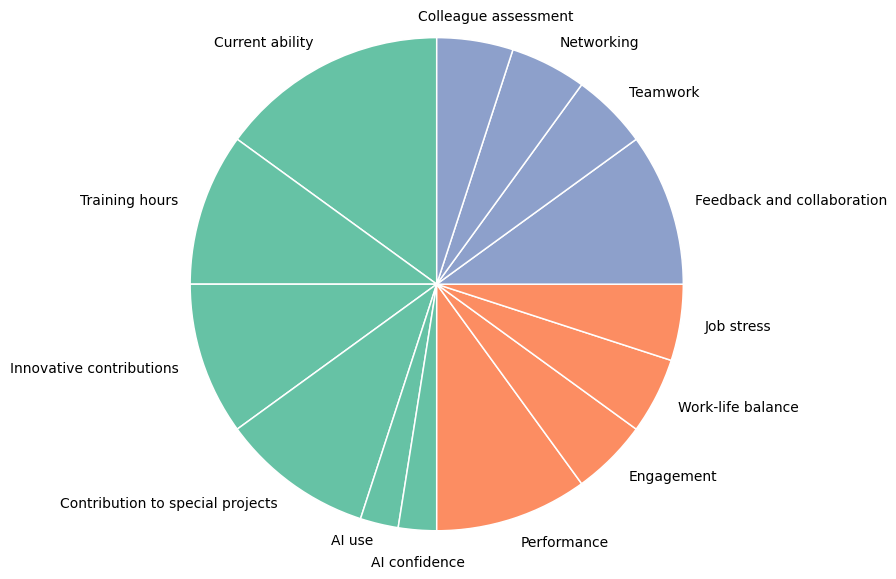

In [33]:
labels = []
sizes = []
colors = []

palette = sns.color_palette("Set2", n_colors=3)
color_map = dict(zip(talent_dict.keys(), palette))

for category, metrics in talent_dict.items():
    for metric, value in metrics.items():
        labels.append(metric)
        sizes.append(value)
        colors.append(color_map[category])

plt.figure(figsize=(7, 7))
wedges, texts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    textprops={"color": "black", "fontsize": 10},
    wedgeprops={"edgecolor": (1,1,1,1), "linewidth":1.1},
    startangle=90,
    labeldistance=1.1,
)

for text in texts:
    if text.get_text() == "AI use":
        x, y = text.get_position()
        text.set_position((x, y + 0.03))
    elif text.get_text() == "AI confidence":
        x, y = text.get_position()
        text.set_position((x + 0.2, y - 0.03))
    elif text.get_text() == "Colleague assessment":
        x, y = text.get_position()
        text.set_position((x - 0.25, y))

plt.axis("equal")
plt.show()

## Talent per sector

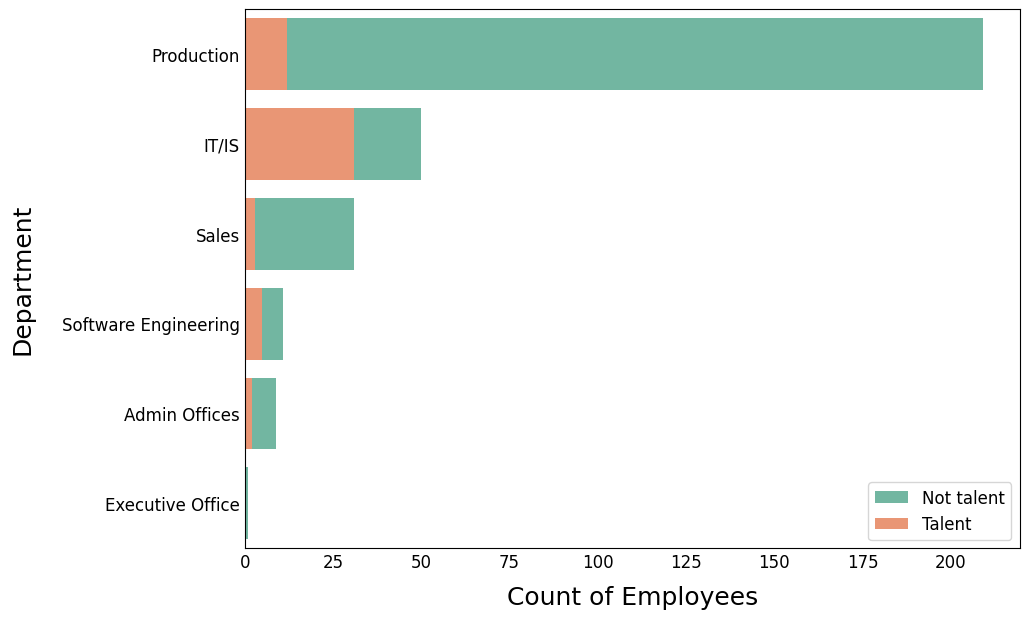

In [34]:
df["Department"] = df["Department"].astype(str).str.strip()

ct = pd.crosstab(df["Department"], df["is_talent"])

counts = ct.fillna(0)
counts["Total"] = counts[0] + counts[1]
counts = counts[counts["Total"] > 0].sort_values("Total", ascending=False)

palette = sns.color_palette("Set2", n_colors=2)

plt.figure(figsize=(10, 7))

sns.barplot(x=counts["Total"], y=counts.index, color=palette[0], label="Not talent")
sns.barplot(x=counts[1], y=counts.index, color=palette[1], label="Talent")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.grid(False)
ax.tick_params(axis="y", length=0, labelsize=12)
ax.tick_params(axis="x", length=0, labelsize=12)

plt.xlabel("Count of Employees", fontsize=18, labelpad=10)
plt.ylabel("Department", fontsize=18, labelpad=20)

plt.legend(loc="lower right", fontsize=12)
plt.show()